# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [36]:
from torch import mps
from torch import cpu
from torch.version import cuda
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# TODO: đặt BATCH_SIZE, EPOCHS, LEARNING_RATE, DATA_DIR
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = "../Homework_B13"
# TODO: chọn DEVICE là 'cuda' nếu torch.cuda.is_available(), ngược lại 'cpu'
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.1.2
Thiết bị: mps


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [37]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True, transform=transform, download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False, transform=transform, download=True)

# TODO: dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
train_set, val_set = random_split(full_train,[100000, 24800])
# TODO: tạo train_loader, val_loader, test_loader với batch_size=BATCH_SIZE
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,shuffle = True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE,shuffle = False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle = False)
print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


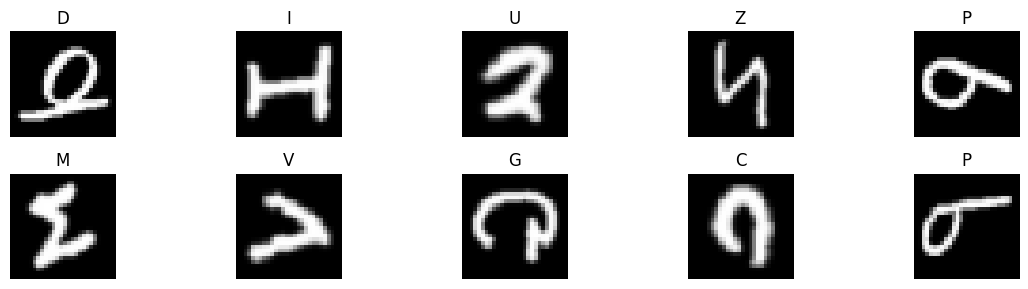

In [38]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# TODO: vẽ 10 ảnh đầu tiên của batch (cmap='gray'), tiêu đề mỗi ảnh là nhãn dạng chữ cái
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch_images[i].squeeze(),cmap='gray')
    plt.title(chr(batch_labels[i].item() + ord('A')-1))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [39]:
from torch import mps
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: định nghĩa các layer
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,26)
        )

    def forward(self, images):
        # TODO: cho images đi qua các layer
        return self.network(images)

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [40]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: lặp qua các batch, cập nhật trọng số, cộng dồn loss và số dự đoán đúng
    # Gợi ý: số dự đoán đúng = (logits.argmax(dim=1) == labels).sum().item()
    for (images,labels) in loader:
        images = images.to(DEVICE)
        labels = (labels-1).to(DEVICE)
        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits,labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)
    
    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = (labels-1).to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim = 1) == labels).sum().item()
            total_samples += labels.size(0)
    # TODO: giống train_one_epoch nhưng bỏ qua backward/step và dùng torch.no_grad()

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [41]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # TODO: gọi train_one_epoch và evaluate, lưu kết quả vào 4 list
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer)
    val_loss, val_acc = evaluate( 
        model=model,
        loader=val_loader,
        criterion=criterion)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    # TODO: in dạng: Epoch {epoch}: train loss=..., val loss=..., train acc=..., val acc=...
    print(f"Epoch {epoch}: train loss={train_loss}, val loss={val_loss},train acc={train_acc}, val acc={val_acc}")

Epoch 1: train loss=1.2334273081970215, val loss=0.8671688528983824,train acc=0.66305, val acc=0.7539516129032258
Epoch 2: train loss=0.7317082496070861, val loss=0.6607888021007661,train acc=0.7908, val acc=0.8079435483870968
Epoch 3: train loss=0.5754145343971252, val loss=0.5512592237995517,train acc=0.83387, val acc=0.8377822580645161
Epoch 4: train loss=0.4918498753452301, val loss=0.4892551833583463,train acc=0.85533, val acc=0.8542741935483871
Epoch 5: train loss=0.43928539786338805, val loss=0.456010617902202,train acc=0.86854, val acc=0.8627016129032258


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

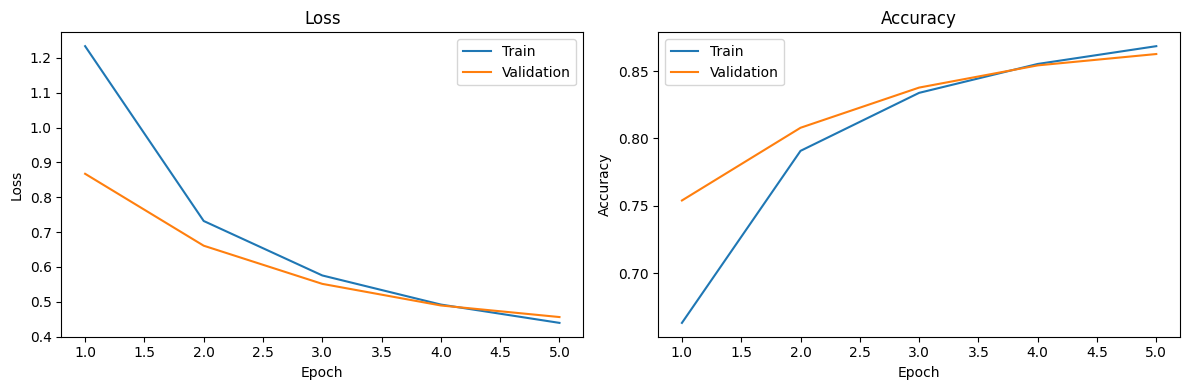

Test loss=0.4643, test accuracy=86.18%


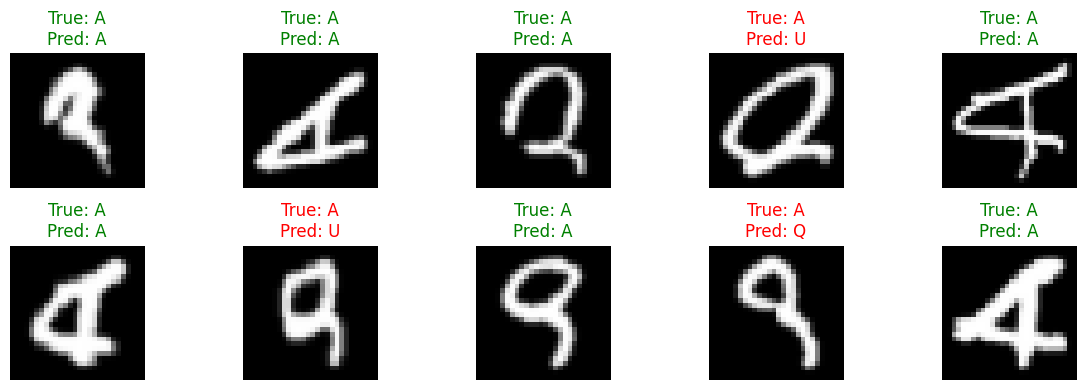

In [42]:
# TODO: vẽ đồ thị Loss và Accuracy theo epoch (train vs val)
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train")
plt.plot(epochs, val_accuracies, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

# TODO: lấy 1 batch từ test_loader và vẽ 10 ảnh kèm nhãn thật + nhãn dự đoán
model.eval()

test_images, test_labels = next(iter(test_loader))
test_labels -= 1
with torch.no_grad():
    logits = model(test_images.to(DEVICE))
    predictions = logits.argmax(dim=1)

plt.figure(figsize=(12, 4))

for i in range(10):
    true_label = chr(test_labels[i].item() + ord('A'))
    pred_label = chr(predictions[i].item() + ord('A'))

    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap='gray')

    color = 'green' if predictions[i].item() == test_labels[i].item() else 'red'

    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color=color
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

- Giá trị test ~86%, phù hợp so với dự kiến của bài toán (85 - 90%)

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [43]:
# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'
torch.save(model.state_dict(), "emnist_mlp.pt")